# Classificazione del dataset Iris con PyTorch

Il dataset **Iris** è uno dei dataset più famosi nel machine learning, introdotto da Ronald Fisher nel 1936.  
Contiene **150 campioni** di fiori di iris suddivisi in **3 specie**:

- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Per ogni campione sono disponibili **4 feature** misurate in centimetri:

| Feature | Descrizione |
|---|---|
| `sepal length` | Lunghezza del sepalo |
| `sepal width` | Larghezza del sepalo |
| `petal length` | Lunghezza del petalo |
| `petal width` | Larghezza del petalo |

L'obiettivo è costruire un modello che, date le 4 misurazioni, **predica correttamente la specie**.

---

In questo notebook confrontiamo diversi approcci di classificazione:
1. Modelli classici di sklearn (Perceptron, Logistic Regression, KNN, SVM)
2. Una rete neurale semplice implementata in **PyTorch** con supporto **MPS** (GPU Apple Silicon)


## 1. Import delle librerie

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.nn.functional as F

## 2. Configurazione del device

PyTorch supporta diversi backend per il calcolo:
- **CUDA**: GPU NVIDIA (Linux/Windows)
- **MPS** (Metal Performance Shaders): GPU Apple Silicon (M1/M2/M3/M4)
- **CPU**: fallback universale

Su Mac M4 utilizziamo **MPS** per sfruttare la GPU integrata nel chip Apple.


In [3]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print("Using device:", device)

Using device: mps


## 3. Caricamento e analisi del dataset

Utilizziamo il dataset Iris direttamente da scikit-learn, che lo include nativamente.  
Questo è preferibile rispetto al caricamento da URL esterni (più stabile, nessuna dipendenza di rete).

Il target `y` è già codificato come intero:
- `0` → *Iris setosa*
- `1` → *Iris versicolor*
- `2` → *Iris virginica*


In [4]:
# Caricamento del dataset
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target  # già numerico: 0, 1, 2

# Nomi delle classi per report e visualizzazioni
class_names = iris.target_names
print("Classi:", class_names)
print("Shape X:", X.shape)
print("\nPrime 5 righe:")
X.head()

Classi: ['setosa' 'versicolor' 'virginica']
Shape X: (150, 4)

Prime 5 righe:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# Statistiche descrittive
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 4. Train/Test split

Dividiamo il dataset in:
- **80% training set** → usato per addestrare i modelli
- **20% test set** → usato per valutare le performance su dati mai visti

`random_state=11` garantisce la riproducibilità della suddivisione.  
`shuffle=True` mescola i dati prima di dividere (importante perché nel dataset originale le classi sono ordinate).


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11, shuffle=True
)

print(f"Training set: {X_train.shape[0]} campioni")
print(f"Test set:     {X_test.shape[0]} campioni")

Training set: 120 campioni
Test set:     30 campioni


## 5. Normalizzazione delle feature

La **standardizzazione** trasforma ogni feature in modo che abbia media 0 e deviazione standard 1:

$$z = \frac{x - \mu}{\sigma}$$

È fondamentale per:
- **Reti neurali**: i pesi vengono inizializzati su scale simili, il che accelera la convergenza
- **KNN e SVM**: questi algoritmi sono sensibili alla scala delle feature (distanze euclidee)
- **Perceptron e Logistic Regression**: convergono più velocemente con dati normalizzati

> ⚠️ Il `fit` si fa **solo sul training set** per evitare *data leakage*:  
> non dobbiamo "vedere" le statistiche del test set durante il training.


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform sul train
X_test_scaled  = scaler.transform(X_test)         # solo transform sul test

## 6. Modelli classici di classificazione (sklearn)

Prima di passare alla rete neurale, addestriamo alcuni modelli classici come baseline.

### Perceptron
Il Perceptron è il precursore delle reti neurali: un singolo neurone lineare con funzione di attivazione a gradino.  
Converge solo se i dati sono linearmente separabili.

### Logistic Regression
Nonostante il nome, è un classificatore. Modella la probabilità di appartenenza a una classe tramite la funzione sigmoide/softmax.

### K-Nearest Neighbors (KNN)
Classifica un campione in base alla classe maggioritaria tra i suoi `k` vicini più prossimi nello spazio delle feature.

### Support Vector Machine (SVM)
Trova l'iperpiano che massimizza il margine tra le classi. Con kernel non lineare può separare classi non linearmente separabili.


In [8]:
modelli = {
    "Perceptron":           Perceptron(max_iter=1000, random_state=11),
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=11),
    "KNN (k=5)":            KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF kernel)":     SVC(kernel='rbf', random_state=11),
}

risultati = {}
for nome, modello in modelli.items():
    modello.fit(X_train_scaled, y_train)
    y_pred = modello.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    risultati[nome] = acc
    print(f"{nome:<25} Accuracy: {acc:.4f}")

Perceptron                Accuracy: 0.8000
Logistic Regression       Accuracy: 0.9000
KNN (k=5)                 Accuracy: 0.9000
SVM (RBF kernel)          Accuracy: 0.9333


## 7. Rete Neurale con PyTorch

### Architettura

Definiamo una rete neurale **fully connected** (Multi-Layer Perceptron) con:

```
Input (4 feature) → Hidden Layer (16 neuroni, ReLU) → Output (3 classi)
```

- **`nn.Linear(4, 16)`**: strato lineare che apprende pesi W e bias b → $y = Wx + b$
- **`F.relu`**: funzione di attivazione ReLU → $f(x) = \max(0, x)$ — introduce non-linearità
- **`nn.Linear(16, 3)`**: strato di output con 3 neuroni (uno per classe)

Non applichiamo softmax nell'ultimo strato perché `CrossEntropyLoss` la include internamente.


In [9]:
class IrisNN(nn.Module):
    def __init__(self):
        super(IrisNN, self).__init__()
        self.fc1 = nn.Linear(4, 16)   # 4 input → 16 neuroni nascosti
        self.fc2 = nn.Linear(16, 3)   # 16 → 3 classi di output

    def forward(self, x):
        x = F.relu(self.fc1(x))       # attivazione ReLU sul primo strato
        x = self.fc2(x)               # output grezzo (logits)
        return x

model = IrisNN().to(device)
print(model)
print(f"\nParametri totali: {sum(p.numel() for p in model.parameters())}") 

IrisNN(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

Parametri totali: 131


### Conversione in tensori PyTorch

PyTorch lavora con **tensori**, non con array NumPy o DataFrame pandas.  
Dobbiamo quindi convertire i dati e spostarli sul device corretto (MPS/CPU).

- Le feature usano `dtype=torch.float32` (numeri in virgola mobile)
- I target usano `dtype=torch.long` (interi, richiesto da `CrossEntropyLoss`)


In [10]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train,        dtype=torch.long).to(device)
y_test_t  = torch.tensor(y_test,         dtype=torch.long).to(device)

print("Shape tensori:")
print(f"  X_train: {X_train_t.shape} | device: {X_train_t.device}")
print(f"  y_train: {y_train_t.shape} | device: {y_train_t.device}")

Shape tensori:
  X_train: torch.Size([120, 4]) | device: mps:0
  y_train: torch.Size([120]) | device: mps:0


### Loss function e Optimizer

- **`CrossEntropyLoss`**: loss standard per classificazione multiclasse. Combina log-softmax e negative log-likelihood.
- **`Adam`**: optimizer adattivo che aggiusta automaticamente il learning rate per ogni parametro. Generalmente converge più velocemente di SGD classico.
  - `lr=0.01`: learning rate iniziale


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

### Training loop

Ad ogni **epoch** (passaggio completo sul training set):

1. `optimizer.zero_grad()` — azzera i gradienti accumulati dall'iterazione precedente
2. `model(X_train_t)` — **forward pass**: calcola le predizioni
3. `criterion(outputs, y_train_t)` — calcola la **loss**
4. `loss.backward()` — **backpropagation**: calcola i gradienti rispetto a tutti i parametri
5. `optimizer.step()` — **aggiorna i pesi** nella direzione che minimizza la loss


In [12]:
epochs = 100
loss_history = []

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()          # 1. azzera gradienti
    outputs = model(X_train_t)     # 2. forward pass
    loss = criterion(outputs, y_train_t)  # 3. calcola loss
    loss.backward()                # 4. backpropagation
    optimizer.step()               # 5. aggiorna pesi

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{epochs} — Loss: {loss.item():.4f}")

Epoch  10/100 — Loss: 0.6419
Epoch  20/100 — Loss: 0.3533
Epoch  30/100 — Loss: 0.2509
Epoch  40/100 — Loss: 0.2029
Epoch  50/100 — Loss: 0.1643
Epoch  60/100 — Loss: 0.1292
Epoch  70/100 — Loss: 0.1024
Epoch  80/100 — Loss: 0.0853
Epoch  90/100 — Loss: 0.0738
Epoch 100/100 — Loss: 0.0656


### Curva di loss

La loss dovrebbe diminuire nel tempo — se la curva scende regolarmente il modello sta imparando correttamente.


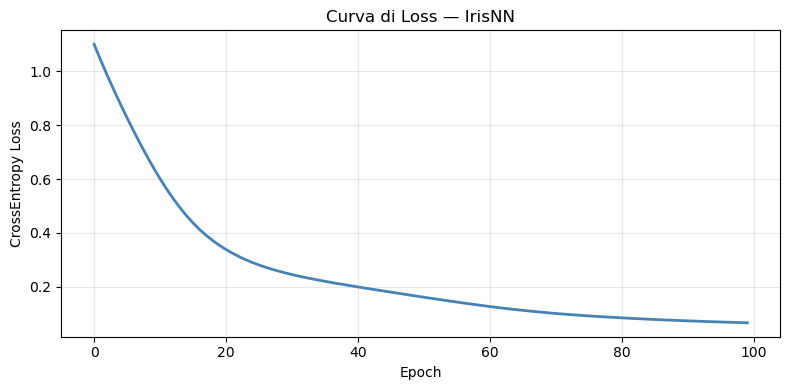

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.title("Curva di Loss — IrisNN")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Valutazione del modello

`model.eval()` disabilita comportamenti specifici del training (es. Dropout, BatchNorm).  
`torch.no_grad()` disabilita il calcolo dei gradienti — non ci serve durante l'inferenza e riduce memoria e tempo.


In [14]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    preds  = torch.argmax(logits, dim=1).cpu().numpy()

acc_nn = accuracy_score(y_test, preds)
risultati["IrisNN (PyTorch)"] = acc_nn

print(f"Accuracy IrisNN: {acc_nn:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, preds, target_names=class_names))

Accuracy IrisNN: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      0.89      0.94         9
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.82      0.90        11

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



### Confusion Matrix

La confusion matrix mostra quante predizioni sono corrette (diagonale) e dove il modello sbaglia (fuori diagonale).


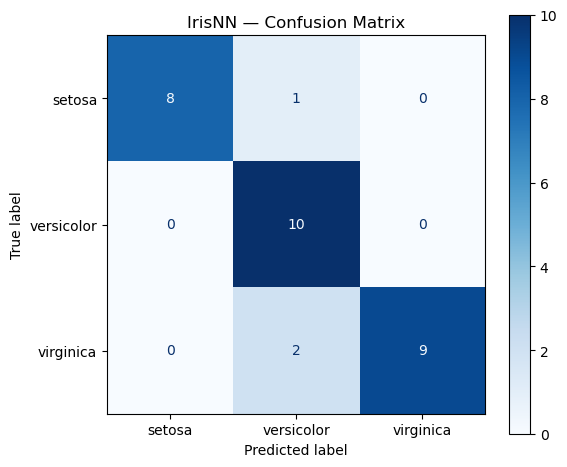

In [15]:
cm   = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)
ax.set_title("IrisNN — Confusion Matrix")
plt.tight_layout()
plt.show()

## 9. Confronto tra modelli

Riepilogo delle accuracy su test set per tutti i modelli addestrati.


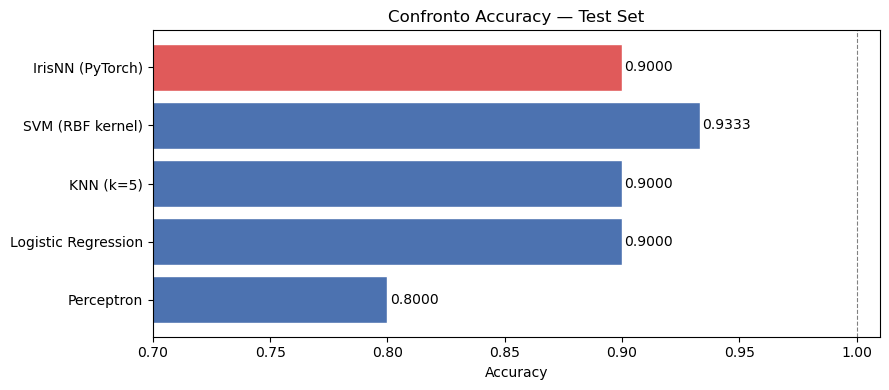

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))

colori = ['#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#E05A5A']
ax.barh(list(risultati.keys()), list(risultati.values()), color=colori, edgecolor='white')
ax.set_xlabel("Accuracy")
ax.set_xlim(0.70, 1.01)
ax.set_title("Confronto Accuracy — Test Set")
ax.axvline(1.0, color='gray', linestyle='--', linewidth=0.8)

for i, (nome, acc) in enumerate(risultati.items()):
    ax.text(acc + 0.001, i, f"{acc:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()